# Lecture 5: RAG & Agentic RAG


RAG란 데이터베이스에서 추가 정보를 검색함으로써 생성된 응답의 정확성과 관련성을 크게 향상시키는 전략이라고 할 수 있습니다.

---

## 환경 설정

- 실습 환경 구축을 위한 패키지 설치 (설치 후 세션을 다시 시작해야합니다.)

In [1]:
!pip install langgraph langchain-upstage langchain==1.1.3 rich langchain-text-splitters langchain_classic qdrant_client langchain_qdrant langchain_tavily

- Google Colab의 '보안 비밀번호(Secrets)' 메뉴에 등록한 API KEY를 환경 변수로 불러옵니다.

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

# 설정할 키 목록
keys = [
    'LANGSMITH_API_KEY', 'UPSTAGE_API_KEY', 'TAVILY_API_KEY'
]

for key in keys:
    value = os.getenv(key)
    if value is None:
        print(f"경고: {key}를 .env에서 찾을 수 없습니다.")
    else:
        os.environ[key] = value

# 고정값 설정
os.environ["LANGSMITH_TRACING_V2"] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = 'agentic-workflow'

- 실습에 필요한 라이브러리 로드 및 LLM 모델 초기화

In [3]:
from rich import print as rprint
from langchain.chat_models import init_chat_model

MODEL = "solar-pro2"
llm = init_chat_model(
    model=MODEL,
    temperature=0.0
)

## Part1: Basic RAG

### Loader

- Document Parser
    - `UpstageDocumentParseLoader`는 PDF, 이미지 등의 문서를 구조화된 형식으로 변환합니다.
    - 참고: https://developers.hyundaimotorgroup.com/blog/623

-  DP 주요 기능
    - 문서 레이아웃 정보 추출: 객체 감지 모델을 사용하여 레이아웃 정보를 정확하게 추출합니다.
    - 레이아웃 박스의 순서 파악: 레이아웃 박스를 사람이 읽는 순서대로 배열하여 정보의 맥락을 유지합니다.
    - 테이블 구조 정보 추출: 복잡한 테이블 구조를 정확하게 이해하고 추출하여 데이터 활용도를 높입니다.
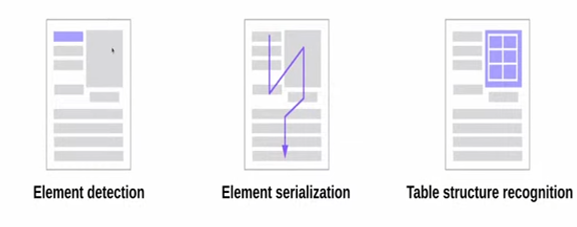


- OCR과 DP 비교

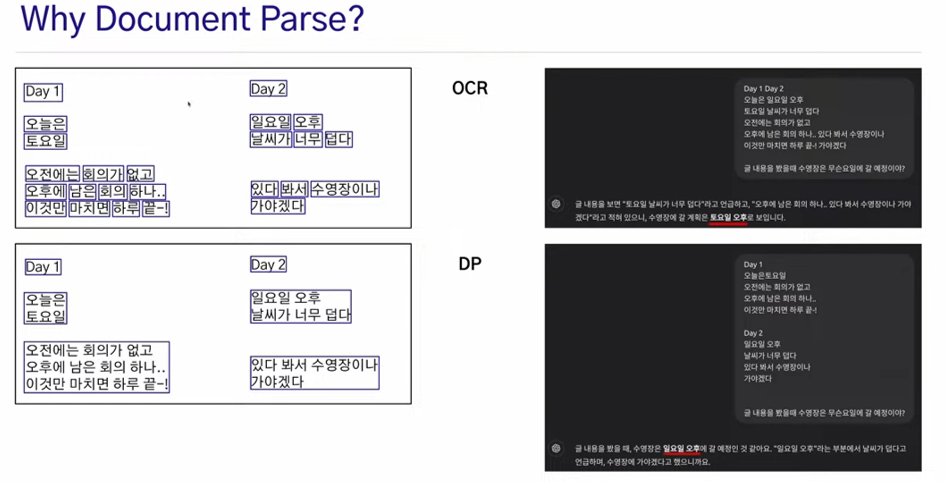

- 주요 파라미터

| 파라미터 | 타입 | 기본값 | 설명 |
|---------|------|--------|------|
| `file_path` | str / List[str] | - | 문서 경로 (단일 또는 복수) |
| `split` | `"none"` / `"page"` / `"element"` | `"none"` | 분할 방식 |
| `output_format` | `"text"` / `"html"` / `"markdown"` | `"html"` | 출력 형식 |
| `coordinates` | bool | `True` | 요소 좌표 포함 여부 |


- 사용할 문서: [AgentOps & Eval에 관한 구글 백서](https://www.kaggle.com/whitepaper-agent-companion)

In [4]:
# https://drive.google.com/file/d/1GVPdwEh48bErTNdhxD0vqxPAifSx1I6Y/view - d/ 와 /view 사이에 있는 아이디 값을 사용합니다.

!gdown --id 1GVPdwEh48bErTNdhxD0vqxPAifSx1I6Y -O Agents_Companion_v2.pdf

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1GVPdwEh48bErTNdhxD0vqxPAifSx1I6Y
To: /content/Agents_Companion_v2.pdf
100% 11.1M/11.1M [00:00<00:00, 23.5MB/s]


In [5]:
from langchain_upstage import UpstageDocumentParseLoader


# PDF 파일 경로
file_path = "Agents_Companion_v2.pdf"

# UpstageDocumentParseLoader로 PDF 파싱
# output_format="html"로 설정하면 Markdown 형식으로 결과를 받음
loader = UpstageDocumentParseLoader(
    file_path,
    output_format="markdown",  # Markdown 형식 출력
    coordinates=False       # 좌표 정보 불포함
)

# 문서 로드
raw_pages = loader.load()

print(f"✅ PDF 파싱 완료: 총 {len(raw_pages)}개 페이지")
print(f"\n[첫 페이지 Markdown 샘플 (500자)]")
print(raw_pages[0].page_content[:500] if raw_pages else "페이지 없음")

✅ PDF 파싱 완료: 총 1개 페이지

[첫 페이지 Markdown 샘플 (500자)]
Agents CompanionAuthors: Antonio Gulli, Lavi Nigam,
Julia Wiesinger, Vladimir Vuskovic,
Irina Sigler, Ivan Nardini, Nicolas Stroppa,
Sokratis Kartakis, Narek Saribekyan,
Anant Nawalgaria, and Alan BountAgents CompanionAcknowledgementsEditors & curatorsAnant NawalgariaContent contributorsSteven JohnsonHussain ChinoyDesignerMichael LanningFebruary 20252# Table of contentsIntroduction 6
AgentOps 8
Agent Success Metrics 12
Agent Evaluation 14
Assessing Agent Capabilities 15
Evaluating Trajectory and


### Splitter

- langchain_text_splitters
    - `RecursiveCharacterTextSplitter`: separators(["\n\n", "\n", " ", ""]) 순서대로 재귀 분할합니다. 큰 단위(문단)부터 시도해 chunk_size 초과 시 다음 separator로 넘어갑니다.
    - `CharacterTextSplitter`: 단일 separator(기본 "\n\n")로 한 번 분할 후, chunk_size 초과 chunk을 잘라냅니다.
    - `TokenTextSplitter`: LLM context window에 최적화된 Splitter 방식 입니다. 토큰화한 후 chunk_size를 토큰 단위 분할합니다.
    - 참고자료: https://dev.to/eteimz/understanding-langchains-recursivecharactertextsplitter-2846

In [6]:
from langchain_text_splitters import RecursiveCharacterTextSplitter


# 텍스트 분할기(Text Splitter) 설정
# chunk_size: 각 청크의 최대 글자 수
# chunk_overlap: 청크 간 문맥 유지를 위해 겹치는 글자 수
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,  # chunk size (characters)
    chunk_overlap=200,  # chunk overlap (characters)
    add_start_index=True,  # track index in original document
)

doc_splits = text_splitter.split_documents(raw_pages)

print(f"✅ Chunking 완료: 총 {len(doc_splits)}개 청크")
# print(f"\n[첫 번째 청크 예시]\nID: {doc_splits[0]}\n내용: {doc_splits[0][:200]}...")

print("[첫 번째 청크 예시]")
rprint(doc_splits[0])

print("[두 번째 청크 예시]")
rprint(doc_splits[1])

from collections import Counter
page_counts = Counter(doc.metadata.get("page", 1) for doc in doc_splits)
print("📄 페이지당 청크 개수 확인:")
for page, count in sorted(page_counts.items()):
    print(f"페이지 {page}: {count}개 청크")


✅ Chunking 완료: 총 123개 청크
[첫 번째 청크 예시]


Document(
    metadata={'total_pages': 76, 'start_index': 0},
    page_content='Agents CompanionAuthors: Antonio Gulli, Lavi Nigam,\nJulia Wiesinger, Vladimir Vuskovic,\nIrina 
Sigler, Ivan Nardini, Nicolas Stroppa,\nSokratis Kartakis, Narek Saribekyan,\nAnant Nawalgaria, and Alan 
BountAgents CompanionAcknowledgementsEditors & curatorsAnant NawalgariaContent contributorsSteven JohnsonHussain 
ChinoyDesignerMichael LanningFebruary 20252# Table of contentsIntroduction 6\nAgentOps 8\nAgent Success Metrics 
12\nAgent Evaluation 14\nAssessing Agent Capabilities 15\nEvaluating Trajectory and Tool Use 17\nEvaluating the 
Final Response 20\nHuman-in-the-Loop Evaluation 21\nMore about Agent Evaluation 22\nMultiple Agents & Their 
Evaluation 23\nUnderstanding Multi-Agent Architectures 24\nMulti-Agent Design Patterns and Their Business Impact 
25\nImportant components of Agents 28\nChallenges in Multi-Agent systems 31\nMulti-Agent Evaluation 32Agentic RAG: 
A Critical Evolution in Retrieval-Augmented Generation 33\nAgentic RAG and its Importance 34\nBetter Search, Better
RAG 36'
)

[두 번째 청크 예시]


Document(
    metadata={'total_pages': 76, 'start_index': 781},
    page_content='Challenges in Multi-Agent systems 31\nMulti-Agent Evaluation 32Agentic RAG: A Critical Evolution 
in Retrieval-Augmented Generation 33\nAgentic RAG and its Importance 34\nBetter Search, Better RAG 36\nAgents in 
the enterprise 38\nManager of agents 38\nGoogle Agentspace 40\nNotebookLM Enterprise 41\nGoogle AgentSpace 
Enterprise 43\nFrom agents to contractors 46\nContracts 46\nContract Lifecycle 49\nContract execution 49\nContract 
Negotiation 50\nContract Feedback 51\nSubcontracts 51\nAutomotive AI: Real World Use of Multi-Agent Architecture 
54\nSpecialized Agents 54\nConversational Navigation Agent 54\nConversational Media Search Agent 55\nMessage 
Composition Agent 56\nCar Manual Agent 57\nGeneral Knowledge Agent 57\nPatterns in Use 58Hierarchical Pattern 
58\nDiamond Pattern 59\nPeer-to-Peer 61\nCollaborative Pattern 63\nResponse Mixer Agent 65\nAdaptive Loop Pattern 
66\nAdvantages of Multi-Agent Architecture for Automotive AI 67\nAgent Builder 68\nSummary 69'
)

📄 페이지당 청크 개수 확인:
페이지 1: 123개 청크


### Embedding Machine

- Solar Embedding
    - https://console.upstage.ai/docs/capabilities/embed

In [7]:
from langchain_upstage import UpstageEmbeddings

underlying_embeddings = UpstageEmbeddings(
    model="solar-embedding-1-large"
)

rprint(underlying_embeddings)

UpstageEmbeddings(
    client=<openai.resources.embeddings.Embeddings object at 0x7cebe90c7590>,
    async_client=<openai.resources.embeddings.AsyncEmbeddings object at 0x7cebe7ccb6b0>,
    model='solar-embedding-1-large',
    dimensions=None,
    upstage_api_key=SecretStr('**********'),
    upstage_api_base='https://api.upstage.ai/v1/solar',
    embedding_ctx_length=4096,
    embed_batch_size=10,
    allowed_special=set(),
    disallowed_special='all',
    chunk_size=1000,
    max_retries=2,
    request_timeout=None,
    show_progress_bar=False,
    model_kwargs={},
    skip_empty=False,
    default_headers={'x-upstage-client': 'langchain'},
    default_query=None,
    http_client=None,
    http_async_client=None
)

### VectorStore

- Qdrant
    - 벡터 유사도 검색 엔진입니다.
    - Qdrant와 LangChain을 사용하여 밀집 검색(임베딩 기반 검색), 희소 검색(텍스트 검색) 및 하이브리드 검색을 수행할 수 있습니다.
    - 참고: https://docs.langchain.com/oss/python/integrations/vectorstores/qdrant

- CacheBackedEmbeddings
    - [CacheBackedEmbeddings](https://docs.langchain.com/oss/python/integrations/text_embedding/index#caching):임베딩을 키-값 저장소에 저장하며, 텍스트를 해시하고 해당 해시 값을 캐시의 키로 사용합니다.

In [8]:
from langchain_classic.embeddings import CacheBackedEmbeddings
from langchain_classic.storage import LocalFileStore

from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams
from langchain_qdrant import QdrantVectorStore

# 함수 밖에서 클라이언트 변수를 미리 선언 (최초 1회만 생성하게 함)
_global_qdrant_client = None


def setup_vectorstore(
    underlying_embeddings,
    collection_name,
    documents=None,
):
    """Qdrant 벡터스토어를 생성하고 채웁니다."""

    global _global_qdrant_client

    if _global_qdrant_client is None:
        try:
            print("🚀 Qdrant 클라이언트를 새로 초기화합니다.")
            # 로컬 경로 지정(하드디스크 저장)
            _global_qdrant_client = QdrantClient(path="./qdrant_db")
        except RuntimeError as e:
            # 이미 다른 곳에서 열려있을 때의 예외 처리
            if "already accessed" in str(e):
                print("⚠️ 이미 DB가 사용 중입니다. 기존 연결을 확인하세요.")

    # 캐시 스토어 생성
    store = LocalFileStore("./cache/")

    # CacheBackedEmbeddings로 감싸서 캐싱 활성화
    # 여러번 시행할 경우 캐시 활용 (비용 절약)
    embeddings = CacheBackedEmbeddings.from_bytes_store(
        underlying_embeddings,
        store,
        namespace=underlying_embeddings.model,
    )

    # 컬렉션이 이미 존재하는지 확인 후 없다면 생성
    if not _global_qdrant_client.collection_exists(collection_name):
        print(f"📦 새로운 컬렉션 생성 중: {collection_name}")
        _global_qdrant_client.create_collection(
            collection_name=collection_name,
            vectors_config=VectorParams(
                size=4096,
                distance=Distance.COSINE),
        )

    # VectorStore
    vectorstore = QdrantVectorStore(
        client=_global_qdrant_client,
        collection_name=collection_name,
        embedding=embeddings,
    )

    # documents가 제공된 경우에만 추가
    if documents:
        vectorstore.add_documents(documents)
        print(f"✅ {len(documents)}개의 문서가 추가되었습니다.")
    else:
        print(f"ℹ️ 기존 벡터스토어를 로드했습니다 (추가 문서 없음).")

    return vectorstore

In [9]:
vectorstore = setup_vectorstore(
    documents=doc_splits,
    underlying_embeddings=underlying_embeddings,
    collection_name="Agent_Companion",
)

🚀 Qdrant 클라이언트를 새로 초기화합니다.
📦 새로운 컬렉션 생성 중: Agent_Companion


/usr/local/lib/python3.12/dist-packages/langchain_classic/embeddings/cache.py:58: UserWarning: Using default key encoder: SHA-1 is *not* collision-resistant. While acceptable for most cache scenarios, a motivated attacker can craft two different payloads that map to the same cache key. If that risk matters in your environment, supply a stronger encoder (e.g. SHA-256 or BLAKE2) via the `key_encoder` argument. If you change the key encoder, consider also creating a new cache, to avoid (the potential for) collisions with existing keys.
  _warn_about_sha1_encoder()


✅ 123개의 문서가 추가되었습니다.


- Collection이 생성되었습니다. 생성된 컬렉션을 한번 볼까요.

In [10]:
import sqlite3
import pandas as pd

# 1. DB 연결
db_path = 'qdrant_db/collection/Agent_Companion/storage.sqlite'  # 실제 파일명으로 수정하세요
conn = sqlite3.connect(db_path)

# 2. 어떤 테이블들이 있는지 확인
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"✅ 테이블 목록: {tables}")

# 3. 특정 테이블 내용 확인 (예: 첫 번째 테이블 내용 가져오기)
if tables:
    table_name = tables[0][0]
    query = f"SELECT * FROM {table_name} LIMIT 10" # 상위 10개만 확인
    df = pd.read_sql_query(query, conn)

    # 결과 출력
    display(df.head())

# 연결 종료
conn.close()

✅ 테이블 목록: [('points',)]


,id,point
0,gASVJAAAAAAAAACMIGQ1MWQ3ZDliMDliMTQ5NDNiNmM0N2...,b'\x80\x04\x95\x02\x95\x00\x00\x00\x00\x00\x00...
1,gASVJAAAAAAAAACMIDFkOGM4ZGRiOWJmMDQ4ZDFhNDRmMT...,b'\x80\x04\x95\xdf\x94\x00\x00\x00\x00\x00\x00...
2,gASVJAAAAAAAAACMIGUxNzVjMjNmYzNkMTQ0MTJhZWExMD...,b'\x80\x04\x95\x06\x95\x00\x00\x00\x00\x00\x00...
3,gASVJAAAAAAAAACMIDQzYjBiYzU4ODc3ZjRkNGY4NTM4ZT...,b'\x80\x04\x95\xfb\x94\x00\x00\x00\x00\x00\x00...
4,gASVJAAAAAAAAACMIDI2ZjE3ZDIzNDgyMjRjN2Y4OWI0NG...,b'\x80\x04\x95\x1b\x95\x00\x00\x00\x00\x00\x00...


### Query vectorization

In [11]:
query = "Agent와 Multi-Agent의 차이점은 뭐예요?"
query_embedding = underlying_embeddings.embed_query(query)

### Retriever

In [12]:
results = vectorstore.similarity_search_by_vector(query_embedding, k=3)
rprint(results)

[
    Document(
        metadata={
            'total_pages': 76,
            'start_index': 27607,
            '_id': '143a985e90e144eba1f7ed621eb473ea',
            '_collection_name': 'Agent_Companion'
        },
        page_content='- accurate results.\n- • Improved Efficiency: Agents can work in parallel, speeding up task 
completion.\n- • Better Handling of Complex Tasks: Large tasks can be broken down into smaller, more\n- manageable 
subtasks, with each agent focusing on a specific aspect.\n- • Increased Scalability: The system can be easily 
scaled by adding more agents with\n- specialized capabilities.\n- • Improved Fault Tolerance: If one agent fails, 
others can take over its responsibilities.\n- • Reduced Hallucinations and Bias: By combining the perspectives of 
multiple agents,\n- the system can reduce the effects of hallucinations and bias, leading to more reliable and\n- 
trustworthy outputs.\nUnderstanding Multi-Agent ArchitecturesUnlike traditional monolithic AI systems, multi-agent 
architectures break down a problem\ninto distinct tasks handled by specialized agents. Each agent operates with 
defined roles,\ninteracting dynamically with others to optimize decision-making, knowledge retrieval, and'
    ),
    Document(
        metadata={
            'total_pages': 76,
            'start_index': 29923,
            '_id': 'c73ced716da141d59db5c62b50b5b8cc',
            '_collection_name': 'Agent_Companion'
        },
        page_content='patterns include:February 202525Agents Companion| Type of Multi-Agent System | Description | 
Example |\n| --- | --- | --- |\n| Sequential | Agents work in a sequential manner, with each agent completing its 
task before passing the output to the next agent. | An assembly line, where each worker performs a specific 
operation before passing the product to the next worker. |\n| Hierarchical | Agents are organized in a hierarchical
structure, with a "manager" agent coordinating the workflow and delegating tasks to "worker" agents. | A system 
with a leader agent responsible for making strategic decisions and follower agents executing tasks based on the 
leader\'s instructions. |\n| Collaborative | Agents work together collaboratively, sharing information and 
resources to achieve a common goal. | A team of researchers working on a project, where each member contributes 
their expertise and insights. |'
    ),
    Document(
        metadata={
            'total_pages': 76,
            'start_index': 28406,
            '_id': '231c049edde8476ea2693302a68490cb',
            '_collection_name': 'Agent_Companion'
        },
        page_content='into distinct tasks handled by specialized agents. Each agent operates with defined 
roles,\ninteracting dynamically with others to optimize decision-making, knowledge retrieval, and\nexecution. These
architectures enable more structured reasoning, decentralized problem-\nsolving, and scalable task automation, 
offering a paradigm shift from single-agent workflows.At their core, multi-agent systems leverage principles of 
modularity, collaboration, and\nhierarchy to create a robust AI ecosystem. Agents within these systems can be 
categorized\nbased on their function for example:February 202524Agents Companion- • Planner Agents: Responsible for
breaking down high-level objectives into\n- structured sub-tasks.\n- • Retriever Agents: Optimize knowledge 
acquisition by dynamically fetching relevant data\n- from external sources.\n- • Execution Agents: Perform 
computations, generate responses, or interact with APIs.\n- • Evaluator Agents: Monitor and validate responses, 
ensuring coherence and alignment'
    )
]

### Workflow

In [13]:
from typing_extensions import TypedDict
from typing import Annotated, List, Literal
from langchain_core.documents import Document

from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    user_query: str                             # 사용자 질문
    query_embedding: str                        # 쿼리 임베딩 벡터 (질문 임베딩)
    retrieved_documents: List[Document]         # 검색된 Chunk 리스트
    generated_answer: str                       # LLM이 생성한 답변

def query_vectorization(state: State) -> State:
    query_embedding = underlying_embeddings.embed_query(state['user_query'])
    return {"query_embedding": query_embedding}

def retriever(state: State) -> State:
    results = vectorstore.similarity_search_by_vector(state['query_embedding'], k=5)
    return {"retrieved_documents": results}

def generater(state: State) -> State:
    prompt = f"""
    다음 문서를 참고하여 질문에 답하세요.

    문서:
    {state['retrieved_documents']}

    질문:
    {state['user_query']}
    """

    response = llm.invoke(prompt)
    return {"generated_answer": response}

rag_workflow = StateGraph(State)

rag_workflow.add_node("query_vectorization", query_vectorization)
rag_workflow.add_node("retriever", retriever)
rag_workflow.add_node("generater", generater)

rag_workflow.add_edge(START, "query_vectorization")
rag_workflow.add_edge("query_vectorization", "retriever")
rag_workflow.add_edge("retriever", "generater")
rag_workflow.add_edge("generater", END)

rag_workflow = rag_workflow.compile()

In [14]:
result = rag_workflow.invoke({"user_query": "Agent와 Multi-Agent의 차이점은 뭐예요?"})
print(result["generated_answer"])

content='**Agent와 Multi-Agent 시스템의 차이점**은 다음과 같이 요약할 수 있습니다:\n\n### 1. **단일 Agent 시스템**  \n   - **구조**: 하나의 AI 모델이 전체 작업을 독립적으로 처리합니다.  \n   - **특징**:  \n     - 모든 결정, 지식 검색, 실행을 단일 엔티티가 담당합니다.  \n     - 복잡한 작업은 처리 가능하지만, 확장성이나 오류 복구 측면에서 한계가 있을 수 있습니다.  \n     - 예: 일반적인 챗봇이나 단일 LLM(Large Language Model) 기반 시스템.  \n\n### 2. **Multi-Agent 시스템**  \n   - **구조**: 여러 전문 Agent가 협업하여 작업을 분할 처리합니다.  \n   - **주요 차이점**:  \n     - **분업화**: 각 Agent는 특정 역할(예: 계획, 검색, 실행, 평가)을 수행하며, 복잡한 작업을 작은 하위 작업으로 분해합니다.  \n     - **상호작용**: Agent 간 동적 협력 또는 계층적 조정이 가능합니다(예: 순차적, 계층적, 협력적 패턴).  \n     - **장점**:  \n       - **효율성**: 병렬 처리로 작업 속도 향상.  \n       - **확장성**: 새로운 Agent 추가로 시스템 확장 용이.  \n       - **신뢰성**: 일부 Agent 실패 시 다른 Agent가 대체 가능.  \n       - **정확성**: 다중 관점 통합으로 환각(Hallucination) 및 편향 감소.  \n     - **예시**:  \n       - **자동차 AI**: 대화 내비게이션 Agent, 매뉴얼 검색 Agent 등이 협업.  \n       - **계약 관리**: 계약 협상, 실행, 피드백 Agent가 단계별 작업 분담.  \n\n### 3. **핵심 차이 요약**  \n| **기준**       | **단일 Agent**               | **Mult

## Part 2: Agentic RAG

In [15]:
from langgraph.graph import add_messages
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from pydantic import BaseModel, Field, field_validator
from langgraph.prebuilt import ToolNode

class State(TypedDict):
    messages: Annotated[list, add_messages]

# vectorstore search
if 'vectorstore' not in locals():
    vectorstore = setup_vectorstore(
        documents=doc_splits,
        underlying_embeddings=underlying_embeddings,
        collection_name="solar-embedding-1-large",
    )

class AgentOpsRetrieverInput(BaseModel):
    """Input schema for the AgentOps/LangGraph knowledge base search tool."""

    query: str = Field(
        description="The specific search query to look up in the document database. "
                    "Example: 'How to implement a ReAct agent using LangGraph?'"
    )

    top_k: int = Field(
        default=3,
        ge=1,
        le=10,
        description="The number of relevant document chunks to retrieve. "
                    "Minimum is 1, maximum is 10. Use higher values for complex questions."
    )

    search_type: Literal["similarity", "mmr"] = Field(
        default="similarity",
        description="The retrieval algorithm to use. "
                    "'similarity' for the most relevant results, "
                    "'mmr' (Maximal Marginal Relevance) to ensure diversity and avoid redundancy."
    )

    @field_validator('query')
    @classmethod
    def validate_query(cls, v: str) -> str:
        if len(v.strip()) < 5:
            raise ValueError("The search query is too short! Must be at least 5 characters.")
        return v

@tool("agentops_retriever_tool", args_schema=AgentOpsRetrieverInput)
def agentops_retriever_tool(query: str, top_k: int = 3, search_type: str = "similarity"):
    """
    Search and retrieve technical documentation regarding AI Agents, AgentOps from the internal knowledge base.
    """
    # vectorstore가 사전에 정의되어 있다고 가정합니다.
    retriever = vectorstore.as_retriever(
        search_type=search_type,
        search_kwargs={"k": top_k}
    )
    return retriever.invoke(query)

web_search_tool = TavilySearch()

tools = [agentops_retriever_tool, web_search_tool]
tool_node = ToolNode(tools=tools)
llm_with_tools = llm.bind_tools(tools)

/usr/local/lib/python3.12/dist-packages/langchain_tavily/tavily_research.py:97: UserWarning: Field name "output_schema" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]
/usr/local/lib/python3.12/dist-packages/langchain_tavily/tavily_research.py:97: UserWarning: Field name "stream" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]


In [16]:
def agent(state: State):
    """Agent 노드: LLM이 tools를 바인딩한 상태로 호출합니다.

    LLM이 tool_calls를 생성하면 route 함수에서 "tools"로 라우팅되고,
    tool_calls가 없으면 최종 응답으로 END로 라우팅됩니다.
    """
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


def route(state: State):
    """조건부 라우팅: tool_calls가 있으면 tools 노드로, 없으면 END로 라우팅"""
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")

    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"

    return END  # tool_calls가 없으면 종료

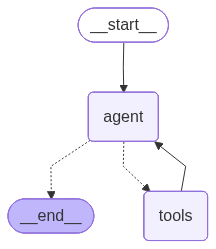

In [17]:
# StateGraph 정의
graph_builder = StateGraph(State)

# 노드 추가
graph_builder.add_node("agent", agent)
graph_builder.add_node("tools", tool_node)

# 엣지 정의
graph_builder.add_edge(START, "agent")
graph_builder.add_conditional_edges(
    "agent",
    route,
    {"tools": "tools", END: END},
)
graph_builder.add_edge("tools", "agent")

# 그래프 컴파일
agentic_rag = graph_builder.compile()

# 그래프 시각화
from IPython.display import Image
display(Image(agentic_rag.get_graph().draw_mermaid_png()))

In [18]:
# Agentic RAG 테스트 실행
def run_agentic_rag(user_input: str):
    """Agentic RAG Agent를 실행하고 결과를 출력합니다."""
    print(f"🔍 질문: {user_input}\n")
    print("-" * 50)

    for event in agentic_rag.stream({"messages": [("user", user_input)]}):
        for node_name, value in event.items():
            if node_name == "agent":
                ai_message = value["messages"][-1]

                # Tool calls가 있으면 어떤 Tool을 호출하는지 출력
                if hasattr(ai_message, "tool_calls") and ai_message.tool_calls:
                    print(f"🔧 Tool 호출:")
                    for tc in ai_message.tool_calls:
                        print(f"   - {tc['name']}: {tc['args']}")
                # 최종 응답이면 출력
                elif ai_message.content:
                    print(f"\n📝 최종 응답:\n{ai_message.content}")

            elif node_name == "tools":
                print(f"✅ Tool 실행 완료")

    print("-" * 50)


# 테스트 실행
run_agentic_rag("AgentOps가 뭐에요?")

🔍 질문: AgentOps가 뭐에요?

--------------------------------------------------
🔧 Tool 호출:
   - agentops_retriever_tool: {'query': 'AgentOps의 핵심 원칙과 구현 사례', 'top_k': 2}
✅ Tool 실행 완료

📝 최종 응답:
AgentOps는 AI 에이전트 시스템의 운영 및 관리를 체계화하기 위한 방법론으로, DevOps와 MLOps의 핵심 원칙을 에이전트 특성에 맞게 확장한 개념입니다. 검색된 내부 문서를 기반으로 핵심 요소를 정리하면 다음과 같습니다:

### 1. **핵심 원칙**
- **DevOps/MLOps 통합**: 기존 소프트웨어 개발 및 머신러닝 운영 모범 사례를 기반으로 구축
- **에이전트 특화 요소**: 
  - 도구 관리(Tool Management)
  - 오케스트레이션(Orchestration)
  - 메모리 관리(Memory)
  - 작업 분해(Task Decomposition)

### 2. **주요 실행 전략**
- **지표 기반 개선(Metrics-Driven Improvement)**:
  - 비즈니스 KPI(목표 달성률, 사용자 참여도, 수익 등)를 "북극성"으로 설정
  - 에이전트 작업 단계(Traces), 사용자 상호작용, 도구 사용 패턴 등 세부 지표 추적
  - 인간 피드백(👍/👎, 설문조사) 수집 시스템 구축

- **자동 평가 프레임워크**:
  - 수동 테스트 의존도 감소
  - 정확한 일치(Exact Match), 순서 일치(In-Order Match), 정밀도/재현율(Precision/Recall) 등 정량적 평가
  - LLM 기반 자동 평가자(Auto-rater)를 활용한 응답 품질 검증

### 3. **기존 시스템과의 관계**
- **상호 보완적**: DevOps/MLOps의 보안, 인증, 예외 처리, 확장성 등 기존 인프라 요구사항은 그대로 유지
- **API 통합**: 에이전트 오케스트레이션에

In [19]:
# 웹 검색이 필요한 질문 테스트 (최신 정보)
run_agentic_rag("2025년 LangGraph의 최신 버전은 무엇인가요?")

🔍 질문: 2025년 LangGraph의 최신 버전은 무엇인가요?

--------------------------------------------------
🔧 Tool 호출:
   - tavily_search: {'query': '2025년 LangGraph 최신 버전', 'start_date': '2024-01-01', 'end_date': '2025-12-31', 'search_depth': 'advanced', 'topic': 'general'}
✅ Tool 실행 완료

📝 최종 응답:
2025년 10월 기준, **LangGraph의 최신 버전은 `v1.0`**으로, 현재 알파 버전 문서가 공개된 상태입니다. 주요 업데이트 내용은 다음과 같습니다:

1. **패키지 단순화**:  
   - `langchain`, `langchain-core`, `langchain-{3rd party integration}`으로 재구성되었으며, 이전 코드는 `langchain-legacy`로 이동했습니다.

2. **에이전트 시스템 강화**:  
   - `create_agent()` 함수로 단일 에이전트 지원, `create_react_agent` 확장 버전인 **미들웨어 기능** 추가 (예: `pre_model_hook`, `post_model_hook`).
   - 단일/멀티 에이전트 통합 및 확장성 개선.

3. **메시지 객체 개선**:  
   - `content_blocks` 추가로 Reasoning 과정, Tool 호출 등을 더 직관적으로 관리 가능.

4. **런타임(Context) 관리**:  
   - `Runtime` 객체를 통해 정적/동적 컨텍스트를 분리하여 권한 제어 등 민감한 작업에 최적화.

5. **도구 통합**:  
   - 외부 작업을 Tool로 통일, 상태 및 컨텍스트 조작을 모델에 위임.

6. **버전 현황**:  
   - 현재 `v0.6.9`이며, 2025년 10월 중 `v1.0` 출시 예정.

### 참고 자료
- [Link